# MSNet Training + Diagnostics on Washington RGB-D

**Complete training pipeline with gradient health monitoring, stream contribution analysis, and internal CNN visualization**

---

## Checklist Before Running:

- [ ] **Enable A100 GPU:** Runtime -> Change runtime type -> Hardware accelerator: GPU -> GPU type: A100
- [ ] **Mount Google Drive:** Your code and dataset will be loaded from the shared drive
- [ ] **Verify dataset on shared drive:** `Shareddrives/MSNN-Capstone/data/washington_rgbd_256.tar.gz` (preprocessed train/val/test splits, 256x256 paired RGB + depth tensors)

---

## What This Notebook Does:

**Training with Full Diagnostics:**
1. Train MSNet (2-stream: RGB + Depth) on Washington RGB-D Object 51-category
2. Gradient health monitoring (vanishing/exploding/oscillating detection)
3. Per-stream training loss decomposition
4. Integration weight evolution tracking
5. Early stopping on `val_mca` with best-weights restoration before the test eval

**Post-Training Visualization Suite:**
6. Feature map visualization (full model, per-stream, ablation)
7. Stream contribution decomposition (what each stream contributes to each neuron)
8. Stream-decomposed Grad-CAM (where each stream focuses attention)
9. Integration weight analysis (learned fusion priorities per layer)
10. Stream redundancy analysis (are streams learning the same thing?)
11. Per-class stream dominance (which classes rely on RGB vs Depth?)
12. Misclassification analysis with Grad-CAM comparison
13. Train vs test activation divergence + BN stats reset experiment

---

## About MSNet:

**MSNet** (Multi-Stream Linear Integration Network) is an N-stream ResNet where fusion happens **inside each convolution neuron**:
- Per-stream independent convolution kernels (full spatial filters)
- Learned 1x1 integration weights that combine stream outputs at every layer
- Integrated pathway carries the fused representation forward

This allows the network to learn **layer-specific, spatially-aware integration strategies**.

## 1. Environment Setup & GPU Verification

In [1]:
# Check GPU availability and specs
import torch
import subprocess

print("=" * 60)
print("GPU VERIFICATION")
print("=" * 60)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

    gpu_name = torch.cuda.get_device_name(0)
    if 'A100' in gpu_name:
        print("\nA100 GPU detected - optimal for training")
    elif 'V100' in gpu_name:
        print("\nV100 GPU detected - good for training (slower than A100)")
    elif 'T4' in gpu_name:
        print("\nT4 GPU detected - will be slower, consider upgrading to A100")
    else:
        print(f"\nGPU: {gpu_name}")
else:
    print("\nNO GPU DETECTED!")
    print("Enable GPU: Runtime -> Change runtime type -> Hardware accelerator: GPU")
    raise RuntimeError("GPU is required for training")

print("\n" + "=" * 60)

GPU VERIFICATION
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU Memory: 94.97 GB

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition



In [2]:
# Detailed GPU info
!nvidia-smi

Wed Apr 29 22:14:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [3]:
from google.colab import drive
import os
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully!")
print(f"\nShared drive contents:")
!ls -la /content/drive/Shareddrives/MSNN-Capstone/ | head -20


Mounted at /content/drive

Google Drive mounted successfully!

Shared drive contents:
total 16570
-rw------- 1 root root   64683 Apr 29 06:27 colab_MSNet_Washington_hype_tune_completed.ipynb
-rw------- 1 root root  710008 Apr 28 02:26 colab_MSNet_Washington_training_baselines_completed.ipynb
-rw------- 1 root root 4832932 Apr 27 11:26 colab_MSNet_Washington_training_baselines_HPO_completed.ipynb
drwx------ 2 root root    4096 Apr 25 16:57 data
-rw------- 1 root root     179 Apr 18 04:06 Detailed Project Plan, Table Format.gsheet
-rw------- 1 root root 2551344 Mar 26 23:32 Gemini_Generated_Image_3hnh623hnh623hnh.jpeg
-rw------- 1 root root 2167910 Mar 26 23:30 Gemini_Generated_Image_bnh89ubnh89ubnh8.jpeg
-rw------- 1 root root 1994897 Mar 24 17:19 Gemini_Generated_Image_tdhovmtdhovmtdho.jpeg
-rw------- 1 root root 2125762 Mar 27 00:27 Gemini_Generated_Image_ttj15qttj15qttj1.jpeg
drwx------ 2 root root    4096 Apr 17 06:02 msnet_checkpoints
-rw------- 1 root root     179 Apr 27 01:28 MSN

## 3. Clone Repository to Local Disk (Fast I/O)

**Important:** We clone to `/content/` (local SSD) instead of Drive for 10-20x faster I/O

**Default:** Clone from GitHub (recommended - always gets latest code)

In [4]:
import os
from pathlib import Path

# Configuration
PROJECT_NAME = "MSNN-Capstone"
GITHUB_REPO = "https://github.com/clingergab/MSNN-Capstone.git"
LOCAL_REPO_PATH = f"/content/{PROJECT_NAME}"

print("=" * 60)
print("REPOSITORY SETUP")
print("=" * 60)

os.chdir('/content')

if Path(LOCAL_REPO_PATH).exists() and Path(f"{LOCAL_REPO_PATH}/.git").exists():
    print(f"Repo already exists: {LOCAL_REPO_PATH}")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
else:
    if Path(LOCAL_REPO_PATH).exists():
        !rm -rf {LOCAL_REPO_PATH}
    print(f"Cloning from {GITHUB_REPO}...")
    !git clone {GITHUB_REPO} {LOCAL_REPO_PATH}
    if not Path(LOCAL_REPO_PATH).exists():
        raise RuntimeError(f"Failed to clone repository")
    os.chdir(LOCAL_REPO_PATH)

print(f"\nWorking directory: {os.getcwd()}")
!ls -la {LOCAL_REPO_PATH}
print("\n" + "=" * 60)

REPOSITORY SETUP
Cloning from https://github.com/clingergab/MSNN-Capstone.git...
Cloning into '/content/MSNN-Capstone'...
remote: Enumerating objects: 284, done.
remote: Counting objects: 100% (284/284), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 284 (delta 84), reused 267 (delta 73), pack-reused 0 (from 0)
Receiving objects: 100% (284/284), 654.22 KiB | 15.58 MiB/s, done.
Resolving deltas: 100% (84/84), done.

Working directory: /content/MSNN-Capstone
total 68
drwxr-xr-x 11 root root 4096 Apr 29 22:15 .
drwxr-xr-x  1 root root 4096 Apr 29 22:15 ..
drwxr-xr-x  5 root root 4096 Apr 29 22:15 configs
drwxr-xr-x  2 root root 4096 Apr 29 22:15 docs
drwxr-xr-x  3 root root 4096 Apr 29 22:15 experiments
drwxr-xr-x  8 root root 4096 Apr 29 22:15 .git
-rw-r--r--  1 root root  732 Apr 29 22:15 .gitattributes
drwxr-xr-x  3 root root 4096 Apr 29 22:15 .github
-rw-r--r--  1 root root  781 Apr 29 22:15 .gitignore
-rw-r--r--  1 root root 1084 Apr 29 22:15 LICENSE
drwxr-xr-

## 4. Install Dependencies

In [5]:
# Install required packages
print("Installing dependencies...")

!pip install -q h5py tqdm matplotlib seaborn ray[tune] kornia thop

# Verify installations
import h5py
import tqdm
import matplotlib
import seaborn
import kornia
import thop

print("All dependencies installed!")
print(f"   h5py: {h5py.__version__}")
print(f"   matplotlib: {matplotlib.__version__}")
print(f"   kornia: {kornia.__version__}")
print(f"   thop: {thop.__version__}")

Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 42.1 MB/s eta 0:00:00
All dependencies installed!
   h5py: 3.16.0
   matplotlib: 3.10.0
   kornia: 0.8.2
   thop: 0.1.1


## 5. Copy Washington RGB-D Dataset to Local Disk

**Performance Note:** Local disk I/O is ~10-20x faster than Drive!

**Dataset:** Washington RGB-D Object 51-category (preprocessed, 256x256 .pt tensors with paired RGB + depth, train/val/test splits)


In [6]:
from pathlib import Path
import os

# Paths
DRIVE_DATASET_TAR = "/content/drive/Shareddrives/MSNN-Capstone/data/washington_rgbd_256.tar.gz"
LOCAL_DATASET_PATH = "/dev/shm/washington_rgbd_256"  # Extracted location

print("=" * 60)
print("WASHINGTON RGB-D OBJECT DATASET SETUP (51 CATEGORIES)")
print("=" * 60)

# Check if already on local disk
if Path(LOCAL_DATASET_PATH).exists():
    print(f"Dataset already on local disk: {LOCAL_DATASET_PATH}")

    # Verify structure
    for split in ['train', 'val', 'test']:
        split_dir = Path(f"{LOCAL_DATASET_PATH}/{split}")
        if split_dir.exists():
            n = len(list(split_dir.glob('*/*_rgb.pt')))
            print(f"   {split.capitalize()} samples: {n}")

# Copy and extract from Drive
elif Path(DRIVE_DATASET_TAR).exists():
    print(f"Found compressed dataset on Drive: {DRIVE_DATASET_TAR}")
    print(f"Copying compressed file to local disk...")

    tar_name = Path(DRIVE_DATASET_TAR).name
    local_tar = f"/dev/shm/{tar_name}"

    !rsync -ah --info=progress2 "{DRIVE_DATASET_TAR}" {local_tar}

    # Extract to local disk
    print(f"\nExtracting dataset to local disk...")
    !tar -xzf {local_tar} -C /dev/shm/ 2>&1 | grep -v "Ignoring unknown extended header"

    # Remove tar file to save space
    !rm {local_tar}

    print(f"\nDataset extracted to local disk")

    for split in ['train', 'val', 'test']:
        split_dir = Path(f"{LOCAL_DATASET_PATH}/{split}")
        if split_dir.exists():
            n = len(list(split_dir.glob('*/*_rgb.pt')))
            print(f"   {split.capitalize()} samples: {n}")

else:
    print(f"Dataset not found on Drive!")
    print(f"   Expected location: {DRIVE_DATASET_TAR}")
    raise FileNotFoundError(f"Compressed dataset not found at {DRIVE_DATASET_TAR}")

for meta in ['class_names.txt', 'norm_stats.json']:
    meta_path = Path(LOCAL_DATASET_PATH) / meta
    status = 'OK' if meta_path.exists() else 'MISSING'
    print(f"   {meta}: {status}")

print("\n" + "=" * 60)
print(f"Dataset ready at: {LOCAL_DATASET_PATH}")
print("=" * 60)


WASHINGTON RGB-D OBJECT DATASET SETUP (51 CATEGORIES)
Found compressed dataset on Drive: /content/drive/Shareddrives/MSNN-Capstone/data/washington_rgbd_256.tar.gz
Copying compressed file to local disk...
        770.62M 100%   75.24MB/s    0:00:09 (xfr#1, to-chk=0/1)

Extracting dataset to local disk...

Dataset extracted to local disk
   Train samples: 10500
   Val samples: 2250
   Test samples: 2250
   class_names.txt: OK
   norm_stats.json: OK

Dataset ready at: /dev/shm/washington_rgbd_256


## 6. Setup Python Path & Import MSNet

In [7]:
import sys
import os

# Remove cached modules
modules_to_reload = [k for k in sys.modules.keys() if k.startswith('src.')]
for module in modules_to_reload:
    del sys.modules[module]

# Add project to Python path
project_root = '/content/MSNN-Capstone'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Verify project structure
print("Project structure:")
!ls -la {project_root}/src/models/

# Import MSNet, dataloaders, and visualization tools
print("\nImporting MSNet, dataloaders, and visualization tools...")
from src.models.linear_integration import ms_resnet18
from src.models.linear_integration.conv import MSBatchNorm2d
from src.data_utils.washington_dataset import (
    get_washington_dataloaders,
    _load_class_names,
    _load_norm_stats,
)
from src.training.augmentation_config import AugmentationConfig

# Import visualization suite
from src.utils.visualization import (
    FeatureMapVisualizer,
    StreamContributionVisualizer,
    StreamGradCAM,
    IntegrationWeightVisualizer,
    find_misclassified,
    compare_samples,
    StreamRedundancyAnalyzer,
    PerClassDominanceAnalyzer,
    ActivationDivergenceAnalyzer,
    IntegrationWeightEvolutionVisualizer,
    reset_bn_stats,
)

print("All imports successful!")


Project structure:
total 36
drwxr-xr-x 8 root root 4096 Apr 29 22:15 .
drwxr-xr-x 7 root root 4096 Apr 29 22:15 ..
drwxr-xr-x 2 root root 4096 Apr 29 22:15 abstracts
drwxr-xr-x 2 root root 4096 Apr 29 22:15 common
drwxr-xr-x 2 root root 4096 Apr 29 22:15 core
drwxr-xr-x 2 root root 4096 Apr 29 22:15 direct_mixing_bn
-rw-r--r-- 1 root root  729 Apr 29 22:15 __init__.py
drwxr-xr-x 2 root root 4096 Apr 29 22:15 linear_integration
drwxr-xr-x 2 root root 4096 Apr 29 22:15 utils

Importing MSNet, dataloaders, and visualization tools...
All imports successful!


In [8]:
# Set random seed for reproducibility
from src.utils.seed import set_seed

SEED = 152
DETERMINISTIC = False  # False = faster, True = fully reproducible

set_seed(SEED, deterministic=DETERMINISTIC)

print(f"Seed: {SEED}, Deterministic: {DETERMINISTIC}")

Seed: 152, Deterministic: False


## 7. Configuration

All hyperparameters and settings in one place. Modify these before running.

In [ ]:
from src.training.augmentation_config import AugmentationConfig

# ======================== DATASET ========================
DATASET_CONFIG = {
    'data_root': LOCAL_DATASET_PATH,
    'batch_size': 64,
    'num_workers': 4,
    'crop_size': 224,
    'num_classes': 51,
    'seed': SEED
}

AUGMENTATION_CONFIG = AugmentationConfig(
    rgb_aug_prob=0.83,
    rgb_aug_mag=0.84,
    depth_aug_prob=0.96,
    depth_aug_mag=1.05,
)

# ======================== MODEL ========================
MODEL_CONFIG = {
    'architecture': 'resnet18',
    'num_classes': 51,
    'stream_input_channels': [3, 1],  # RGB=3, Depth=1
    'width_multiplier': 0.75,
    'dropout_p': 0.49,
    'device': 'cuda',
    'use_amp': True
}

STREAM_LABELS = {0: 'RGB', 1: 'Depth'}

# ======================== OPTIMIZER ========================
STREAM_SPECIFIC_CONFIG = {
    'stream_lrs': 2.35e-04,        # [RGB, Depth]
    'stream_weight_decays': 1.45e-04,  # [RGB, Depth]
    'stem_lr_multiplier': 19.0,  # >1.0 to boost stem LR (changes eta_min to 6 values)
}

SCHEDULER_CONFIG = {
    'scheduler_type': 'cosine',
    't_max': 45,
    'eta_min': 1.95e-06,
    'warmup_epochs': 5,
    'warmup_start_factor': 0.2
}

# ======================== TRAINING ========================
# Train with val_mca-monitored early stopping; on stop, best weights are
# restored before the test set evaluation runs.
TRAIN_CONFIG = {
    'epochs': 50,
    'grad_clip_norm': 1.35,
    'early_stopping': True,
    'patience': 10,
    'min_delta': 0.001,
    'restore_best_weights': True,
    'stream_monitoring': True,
    'modality_dropout': True,
    'modality_dropout_start': 0,
    'modality_dropout_ramp': 0,
    'modality_dropout_rate': 0.52,
    'label_smoothing': 0.09,
    # Gradient health monitoring
    'gradient_monitoring': False,
    'gradient_log_freq': 0,  # Last batch per epoch
    # Integration weight tracking (populates history['integration_weight_norms']
    # and saves full snapshots every integration_snapshot_freq epochs)
    'track_integration_weights': True,
    'integration_snapshot_freq': 10,
    'monitor': 'val_mca',
}

# Print summary
print('All configs defined.')
print(f'  Dataset: {DATASET_CONFIG["data_root"]}')
print(f'  Model: MSNet-{MODEL_CONFIG["architecture"]} ({len(MODEL_CONFIG["stream_input_channels"])}-stream)')
print(f'  Streams: {STREAM_LABELS}')
print(f'  Epochs: {TRAIN_CONFIG["epochs"]}, Grad clip: {TRAIN_CONFIG["grad_clip_norm"]}')
print(f'  Early stopping: {TRAIN_CONFIG["early_stopping"]} (patience={TRAIN_CONFIG["patience"]}, monitor={TRAIN_CONFIG["monitor"]})')
print(f'  Restore best weights: {TRAIN_CONFIG["restore_best_weights"]}')
print(f'  Gradient monitoring: {TRAIN_CONFIG["gradient_monitoring"]}')
print(f'  Integration weight tracking: {TRAIN_CONFIG["track_integration_weights"]}')


## 8. Load Dataset

In [10]:
# Verify dataset structure
from pathlib import Path

print("=" * 60)
print("DATASET STRUCTURE VERIFICATION")
print("=" * 60)

dataset_root = Path(LOCAL_DATASET_PATH)

print("\nDirectory structure:")
print(f"  {dataset_root}/")
for split in ['train', 'val', 'test']:
    split_dir = dataset_root / split
    if split_dir.exists():
        n = len(list(split_dir.glob('*/*_rgb.pt')))
        n_classes = len([d for d in split_dir.iterdir() if d.is_dir()])
        print(f"    {split}/ - {n} paired samples across {n_classes} class folders")

# Read class names
class_names_file = dataset_root / 'class_names.txt'
if class_names_file.exists():
    class_names = _load_class_names(LOCAL_DATASET_PATH)
    print(f"\nClasses ({len(class_names)}):")
    for i, name in enumerate(class_names):
        print(f"  {i}: {name}")

print("\n" + "=" * 60)


DATASET STRUCTURE VERIFICATION

Directory structure:
  /dev/shm/washington_rgbd_256/
    train/ - 10500 paired samples across 51 class folders
    val/ - 2250 paired samples across 44 class folders
    test/ - 2250 paired samples across 44 class folders

Classes (51):
  0: apple
  1: ball
  2: banana
  3: bell_pepper
  4: binder
  5: bowl
  6: calculator
  7: camera
  8: cap
  9: cell_phone
  10: cereal_box
  11: coffee_mug
  12: comb
  13: dry_battery
  14: flashlight
  15: food_bag
  16: food_box
  17: food_can
  18: food_cup
  19: food_jar
  20: garlic
  21: glue_stick
  22: greens
  23: hand_towel
  24: instant_noodles
  25: keyboard
  26: kleenex
  27: lemon
  28: lightbulb
  29: lime
  30: marker
  31: mushroom
  32: notebook
  33: onion
  34: orange
  35: peach
  36: pear
  37: pitcher
  38: plate
  39: pliers
  40: potato
  41: rubber_eraser
  42: scissors
  43: shampoo
  44: soda_can
  45: sponge
  46: stapler
  47: tomato
  48: toothbrush
  49: toothpaste
  50: water_bottle



In [11]:
print("=" * 60)
print("LOADING WASHINGTON RGB-D DATASET (TRAIN + VAL + TEST)")
print("=" * 60)

print(f"\nLoading dataset from: {DATASET_CONFIG['data_root']}")

train_loader, val_loader, test_loader, num_classes = get_washington_dataloaders(
    data_root=DATASET_CONFIG['data_root'],
    batch_size=DATASET_CONFIG['batch_size'],
    num_workers=DATASET_CONFIG['num_workers'],
    crop_size=DATASET_CONFIG['crop_size'],
    seed=DATASET_CONFIG['seed'],
    normalize=True,
    balanced_sampling=True,
    **AUGMENTATION_CONFIG.to_dict(),
)

assert num_classes == DATASET_CONFIG['num_classes'], (
    f"Loader returned num_classes={num_classes} but config expects {DATASET_CONFIG['num_classes']}"
)

print(f"\nDataset loaded!")
print(f"  Train: {len(train_loader.dataset):,} samples ({len(train_loader)} batches)")
print(f"  Val:   {len(val_loader.dataset):,} samples ({len(val_loader)} batches)")
print(f"  Test:  {len(test_loader.dataset):,} samples ({len(test_loader)} batches)")
print(f"  Classes: {num_classes}")

print("\n" + "=" * 60)


LOADING WASHINGTON RGB-D DATASET (TRAIN + VAL + TEST)

Loading dataset from: /dev/shm/washington_rgbd_256

WashingtonRGBD augmentation scaling applied:
  RGB:   prob=0.83, mag=0.84
  Depth: prob=0.96, mag=1.05
  Computed values:
    [Sync]  Flip prob: 0.50 -> 0.448
    [RGB]   ColorJitter prob: 0.43 -> 0.357
    [RGB]   Brightness: +/-0.37 -> +/-0.311
    [RGB]   Blur prob: 0.25 -> 0.207
    [RGB]   Grayscale prob: 0.17 -> 0.141
    [RGB]   Erasing prob: 0.17 -> 0.141
    [Depth] Aug prob: 0.50 -> 0.480
    [Depth] Brightness: +/-0.25 -> +/-0.263
    [Depth] Noise std: 0.059 -> 0.062
    [Depth] Erasing prob: 0.10 -> 0.096
    [Depth] Scale jitter prob: 0.50 -> 0.480
    [Depth] Hole dropout prob: 0.30 -> 0.288

Washington RGB-D Dataset:
  Total samples: 15000
  Train: 10500
  Val: 2250
  Test: 2250
  Classes: 51
  Train batches: 165
  Val batches: 36
  Test batches: 36
  Batch size: 64
  Sampling: weighted

Dataset loaded!
  Train: 10,500 samples (165 batches)
  Val:   2,250 samples (

## 9. Create Model

In [12]:
from src.models.linear_integration import ms_resnet18
from thop import profile


print("=" * 60)
print("MODEL CREATION")
print("=" * 60)

model = ms_resnet18(
    num_classes=MODEL_CONFIG['num_classes'],
    stream_input_channels=MODEL_CONFIG['stream_input_channels'],
    width_multiplier=MODEL_CONFIG['width_multiplier'],
    dropout_p=MODEL_CONFIG['dropout_p'],
    device=MODEL_CONFIG['device'],
    use_amp=MODEL_CONFIG['use_amp']
)

print("\nTraining from scratch (no pretrained backbone).")

print("\n" + "=" * 60)


MODEL CREATION
✅ Enabled Automatic Mixed Precision (AMP) training on cuda

Training from scratch (no pretrained backbone).



## 10. Compile Model (Optimizer + Scheduler)

In [13]:
import os
from datetime import datetime
from pathlib import Path

# Create checkpoint directory on Google Drive (persistent storage)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_dir = f"/content/drive/MyDrive/msnet_checkpoints/run_{timestamp}"

Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)

print(f"Checkpoint directory: {checkpoint_dir}")

Checkpoint directory: /content/drive/MyDrive/msnet_checkpoints/run_20260429_221554


In [14]:
from src.training.optimizers import create_stream_optimizer
from src.training.schedulers import setup_scheduler

print("=" * 60)
print("MODEL COMPILATION")
print("=" * 60)

# Add checkpoint-dependent paths to TRAIN_CONFIG
TRAIN_CONFIG['save_path'] = f"{checkpoint_dir}/best_model.pt"
TRAIN_CONFIG['integration_snapshot_path'] = f"{checkpoint_dir}/integration_snapshots"

optimizer = create_stream_optimizer(
    model,
    optimizer_type='adamw',
    stream_lrs=[STREAM_SPECIFIC_CONFIG['stream_lrs'], STREAM_SPECIFIC_CONFIG['stream_lrs']],
    stream_weight_decays=[STREAM_SPECIFIC_CONFIG['stream_weight_decays'], STREAM_SPECIFIC_CONFIG['stream_weight_decays']],
    shared_lr=STREAM_SPECIFIC_CONFIG['stream_lrs'],
    integration_weight_decay=STREAM_SPECIFIC_CONFIG['stream_weight_decays'],
    stem_lr_multiplier=STREAM_SPECIFIC_CONFIG['stem_lr_multiplier'],
)

scheduler = setup_scheduler(
    optimizer,
    scheduler_type=SCHEDULER_CONFIG['scheduler_type'],
    train_loader_len=len(train_loader),
    t_max=SCHEDULER_CONFIG['t_max'],
    eta_min=(
        ([SCHEDULER_CONFIG['eta_min'] * STREAM_SPECIFIC_CONFIG['stem_lr_multiplier'],
          SCHEDULER_CONFIG['eta_min'] * STREAM_SPECIFIC_CONFIG['stem_lr_multiplier']]
         if STREAM_SPECIFIC_CONFIG['stem_lr_multiplier'] != 1.0 else []) +
        [SCHEDULER_CONFIG['eta_min'], SCHEDULER_CONFIG['eta_min'],
         SCHEDULER_CONFIG['eta_min'], SCHEDULER_CONFIG['eta_min']]
    ),
    warmup_epochs=SCHEDULER_CONFIG['warmup_epochs'],
    warmup_start_factor=SCHEDULER_CONFIG['warmup_start_factor']
)

model.compile(
    optimizer=optimizer,
    scheduler=scheduler,
    loss='cross_entropy',
    label_smoothing=TRAIN_CONFIG['label_smoothing'],
    gpu_augmentation=False,
    **AUGMENTATION_CONFIG.to_dict(),
)

print(f"\nOptimizer: {optimizer.__class__.__name__}")
for i, group in enumerate(optimizer.param_groups):
    num_params = sum(p.numel() for p in group['params'])
    print(f"  Group {i+1}: lr={group['lr']:.2e}, wd={group['weight_decay']:.2e}, params={num_params:,}")
print("\nModel compiled!")
print("=" * 60)


MODEL COMPILATION
MSNet compiled with AdamW optimizer, cross_entropy loss
  Using 6 parameter groups:
    Group 1: lr=8.93e-04, weight_decay=7.63e-06
    Group 2: lr=8.93e-04, weight_decay=7.63e-06
    Group 3: lr=4.70e-05, weight_decay=1.45e-04
    Group 4: lr=4.70e-05, weight_decay=1.45e-04
    Group 5: lr=4.70e-05, weight_decay=1.45e-04
    Group 6: lr=4.70e-05, weight_decay=0.00e+00
  Scheduler: SequentialLR
  Device: cuda, AMP: True

Optimizer: AdamW
  Group 1: lr=8.93e-04, wd=7.63e-06, params=7,056
  Group 2: lr=8.93e-04, wd=7.63e-06, params=2,352
  Group 3: lr=4.70e-05, wd=1.45e-04, params=6,283,296
  Group 4: lr=4.70e-05, wd=1.45e-04, params=6,283,296
  Group 5: lr=4.70e-05, wd=1.45e-04, params=2,761,395
  Group 6: lr=4.70e-05, wd=0.00e+00, params=7,200

Model compiled!


## 11. Train with Full Diagnostics

All diagnostics enabled: gradient health monitoring, per-stream training loss decomposition, integration weight norm tracking + periodic full snapshots, stream-specific accuracy monitoring.

In [ ]:
import warnings
import os

# Suppress PyTorch SequentialLR deprecation warning
warnings.filterwarnings(
    'ignore',
    message='The epoch parameter in `scheduler.step\\(\\)` was not necessary',
    category=UserWarning
)

# Create integration snapshot directory
os.makedirs(TRAIN_CONFIG['integration_snapshot_path'], exist_ok=True)

print("=" * 60)
print("TRAINING WITH FULL DIAGNOSTICS")
print("=" * 60)

print(f"Configuration:")
for key, value in TRAIN_CONFIG.items():
    print(f"  {key}: {value}")


print("=" * 60 + "\n")

# Train: monitor val_mca on the val split. On early stop (or end of training)
# best weights are restored before the test eval below.
history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=TRAIN_CONFIG['epochs'],
    verbose=True,
    save_path=TRAIN_CONFIG['save_path'],
    early_stopping=TRAIN_CONFIG['early_stopping'],
    patience=TRAIN_CONFIG['patience'],
    min_delta=TRAIN_CONFIG['min_delta'],
    restore_best_weights=TRAIN_CONFIG['restore_best_weights'],
    grad_clip_norm=TRAIN_CONFIG['grad_clip_norm'],
    stream_monitoring=TRAIN_CONFIG['stream_monitoring'],
    monitor=TRAIN_CONFIG['monitor'],
    modality_dropout=TRAIN_CONFIG['modality_dropout'],
    modality_dropout_start=TRAIN_CONFIG['modality_dropout_start'],
    modality_dropout_ramp=TRAIN_CONFIG['modality_dropout_ramp'],
    modality_dropout_rate=TRAIN_CONFIG['modality_dropout_rate'],
    # Integration weight tracking — populates history['integration_weight_norms']
    # and writes full per-layer snapshots every integration_snapshot_freq epochs
    track_integration_weights=TRAIN_CONFIG['track_integration_weights'],
    integration_snapshot_path=TRAIN_CONFIG['integration_snapshot_path'],
    integration_snapshot_freq=TRAIN_CONFIG['integration_snapshot_freq'],
    # # Gradient health monitoring (enable by flipping TRAIN_CONFIG['gradient_monitoring'])
    # gradient_monitoring=TRAIN_CONFIG['gradient_monitoring'],
    # gradient_log_freq=TRAIN_CONFIG['gradient_log_freq'],
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)


## 12. Single-Stream Robustness Evaluation

How much does the model degrade when a stream is missing? Tests full model, RGB-only, and Depth-only.

In [16]:
print("\n" + "=" * 60)
print("SINGLE-STREAM ROBUSTNESS EVALUATION (TEST SET)")
print("=" * 60)
print("\nTesting model performance with missing streams...\n")

# Evaluate with all streams (normal)
print("[1/3] Evaluating with BOTH streams (normal):")
results_both = model.evaluate(test_loader, stream_monitoring=True)
print(f"      Accuracy: {results_both['accuracy']*100:.2f}%  MCA: {results_both['mean_class_accuracy']*100:.2f}%")

# Evaluate with RGB only (Depth blanked)
print("\n[2/3] Evaluating with RGB ONLY (Depth blanked):")
results_rgb_only = model.evaluate(test_loader, stream_monitoring=True, blanked_streams={1})
print(f"      Accuracy: {results_rgb_only['accuracy']*100:.2f}%  MCA: {results_rgb_only['mean_class_accuracy']*100:.2f}%")

# Evaluate with Depth only (RGB blanked)
print("\n[3/3] Evaluating with DEPTH ONLY (RGB blanked):")
results_depth_only = model.evaluate(test_loader, stream_monitoring=True, blanked_streams={0})
print(f"      Accuracy: {results_depth_only['accuracy']*100:.2f}%  MCA: {results_depth_only['mean_class_accuracy']*100:.2f}%")

print("\n" + "=" * 60)
print("ROBUSTNESS SUMMARY")
print("=" * 60)
print(f"\n  Both streams:  Acc={results_both['accuracy']*100:.2f}%  MCA={results_both['mean_class_accuracy']*100:.2f}%")
print(f"  RGB only:      Acc={results_rgb_only['accuracy']*100:.2f}%  MCA={results_rgb_only['mean_class_accuracy']*100:.2f}% (Depth missing)")
print(f"  Depth only:    Acc={results_depth_only['accuracy']*100:.2f}%  MCA={results_depth_only['mean_class_accuracy']*100:.2f}% (RGB missing)")

rgb_degradation = (results_both['accuracy'] - results_rgb_only['accuracy']) * 100
depth_degradation = (results_both['accuracy'] - results_depth_only['accuracy']) * 100

print(f"\n  Degradation when Depth missing: {rgb_degradation:+.2f}%")
print(f"  Degradation when RGB missing:   {depth_degradation:+.2f}%")
print("\n" + "=" * 60)


SINGLE-STREAM ROBUSTNESS EVALUATION (TEST SET)

Testing model performance with missing streams...

[1/3] Evaluating with BOTH streams (normal):
      Accuracy: 80.93%  MCA: 80.50%

[2/3] Evaluating with RGB ONLY (Depth blanked):
      Accuracy: 62.76%  MCA: 61.91%

[3/3] Evaluating with DEPTH ONLY (RGB blanked):
      Accuracy: 64.27%  MCA: 63.45%

ROBUSTNESS SUMMARY

  Both streams:  Acc=80.93%  MCA=80.50%
  RGB only:      Acc=62.76%  MCA=61.91% (Depth missing)
  Depth only:    Acc=64.27%  MCA=63.45% (RGB missing)

  Degradation when Depth missing: +18.18%
  Degradation when RGB missing:   +16.67%



## 13. Test Set Evaluation + Pathway Analysis

In [17]:
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

# Evaluate on test set
results = model.evaluate(data_loader=test_loader, stream_monitoring=True)

print(f"\nTest Results:")
print(f"  Loss: {results['loss']:.4f}")
print(f"  Overall Accuracy: {results['accuracy']*100:.2f}%")
print(f"  Mean Class Accuracy: {results['mean_class_accuracy']*100:.2f}%")

print(f"\nStream-Specific Performance:")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    other = (i + 1) % 2
    solo_acc = results[f'stream_{other}_blanked_acc']
    print(f"  Stream{i} ({STREAM_LABELS[i]}) Solo Accuracy: {solo_acc*100:.2f}%")
    print(f"  Stream{i} ({STREAM_LABELS[i]}) Contribution: {results[f'stream_{i}_contribution']*100:+.2f}%")

# Pathway analysis
print(f"\n{'='*60}")
print("PATHWAY ANALYSIS")
print(f"{'='*60}")
print(f"\nAnalyzing stream pathways and integrated pathway contributions...")

pathway_analysis = model.analyze_pathways(data_loader=test_loader)

print(f"\nSamples analyzed: {pathway_analysis['samples_analyzed']}")

# Accuracy
print("\nAccuracy:")
print(f"  Full model:      {pathway_analysis['accuracy']['full_model']*100:.2f}%")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    acc = pathway_analysis['accuracy'][f'stream{i}_only']
    contrib = pathway_analysis['accuracy'][f'stream{i}_contribution']
    print(f"  {STREAM_LABELS[i]} only:       {acc*100:.2f}%  (contribution ratio: {contrib:.3f})")
# acc_int = pathway_analysis['accuracy']['integrated_only']
# contrib_int = pathway_analysis['accuracy']['integrated_contribution']
# print(f"  Integrated only: {acc_int*100:.2f}%  (contribution ratio: {contrib_int:.3f})")

# Loss
print("\nLoss:")
print(f"  Full model:      {pathway_analysis['loss']['full_model']:.4f}")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    loss_i = pathway_analysis['loss'][f'stream{i}_only']
    loss_contrib = pathway_analysis['loss'][f'stream{i}_contribution']
    print(f"  {STREAM_LABELS[i]} only:       {loss_i:.4f}  (loss ratio: {loss_contrib:.3f})")
# loss_int = pathway_analysis['loss']['integrated_only']
# loss_int_contrib = pathway_analysis['loss']['integrated_contribution']
# print(f"  Integrated only: {loss_int:.4f}  (loss ratio: {loss_int_contrib:.3f})")

# Feature norms
print("\nFeature Norms (mean +/- std):")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    mean = pathway_analysis['feature_norms'][f'stream{i}_mean']
    std = pathway_analysis['feature_norms'][f'stream{i}_std']
    print(f"  {STREAM_LABELS[i]}:        {mean:.4f} +/- {std:.4f}")
int_mean = pathway_analysis['feature_norms']['integrated_mean']
int_std = pathway_analysis['feature_norms']['integrated_std']
print(f"  Integrated:  {int_mean:.4f} +/- {int_std:.4f}")

# Training summary
print(f"\n{'='*60}")
print("TRAINING SUMMARY")
print(f"{'='*60}")
print(f"  Initial train loss: {history['train_loss'][0]:.4f}")
print(f"  Final train loss:   {history['train_loss'][-1]:.4f}")
print(f"  Initial train acc:  {history['train_accuracy'][0]*100:.2f}%")
print(f"  Final train acc:    {history['train_accuracy'][-1]*100:.2f}%")
print(f"  Test accuracy:      {results['accuracy']*100:.2f}%")
print(f"  Test MCA:           {results['mean_class_accuracy']*100:.2f}%")
print(f"  Total epochs:       {len(history['train_loss'])}")

print("\n" + "=" * 60)

TEST SET EVALUATION

Test Results:
  Loss: 1.4555
  Overall Accuracy: 80.93%
  Mean Class Accuracy: 80.50%

Stream-Specific Performance:
  Stream0 (RGB) Solo Accuracy: 62.76%
  Stream0 (RGB) Contribution: +16.67%
  Stream1 (Depth) Solo Accuracy: 64.27%
  Stream1 (Depth) Contribution: +18.18%

PATHWAY ANALYSIS

Analyzing stream pathways and integrated pathway contributions...

Samples analyzed: 2250

Accuracy:
  Full model:      80.93%
  RGB only:       64.27%  (contribution ratio: 0.167)
  Depth only:       62.76%  (contribution ratio: 0.182)

Loss:
  Full model:      1.4555
  RGB only:       1.9015  (loss ratio: 1.306)
  Depth only:       1.8996  (loss ratio: 1.305)

Feature Norms (mean +/- std):
  RGB:        46.6404 +/- 19.2876
  Depth:        49.0863 +/- 30.2436
  Integrated:  20.5897 +/- 3.8066

TRAINING SUMMARY
  Initial train loss: 3.8921
  Final train loss:   1.1153
  Initial train acc:  2.16%
  Final train acc:    90.47%
  Test accuracy:      80.93%
  Test MCA:           80.50

## 14. Training Curves + Gradient Health + Stream Loss Decomposition

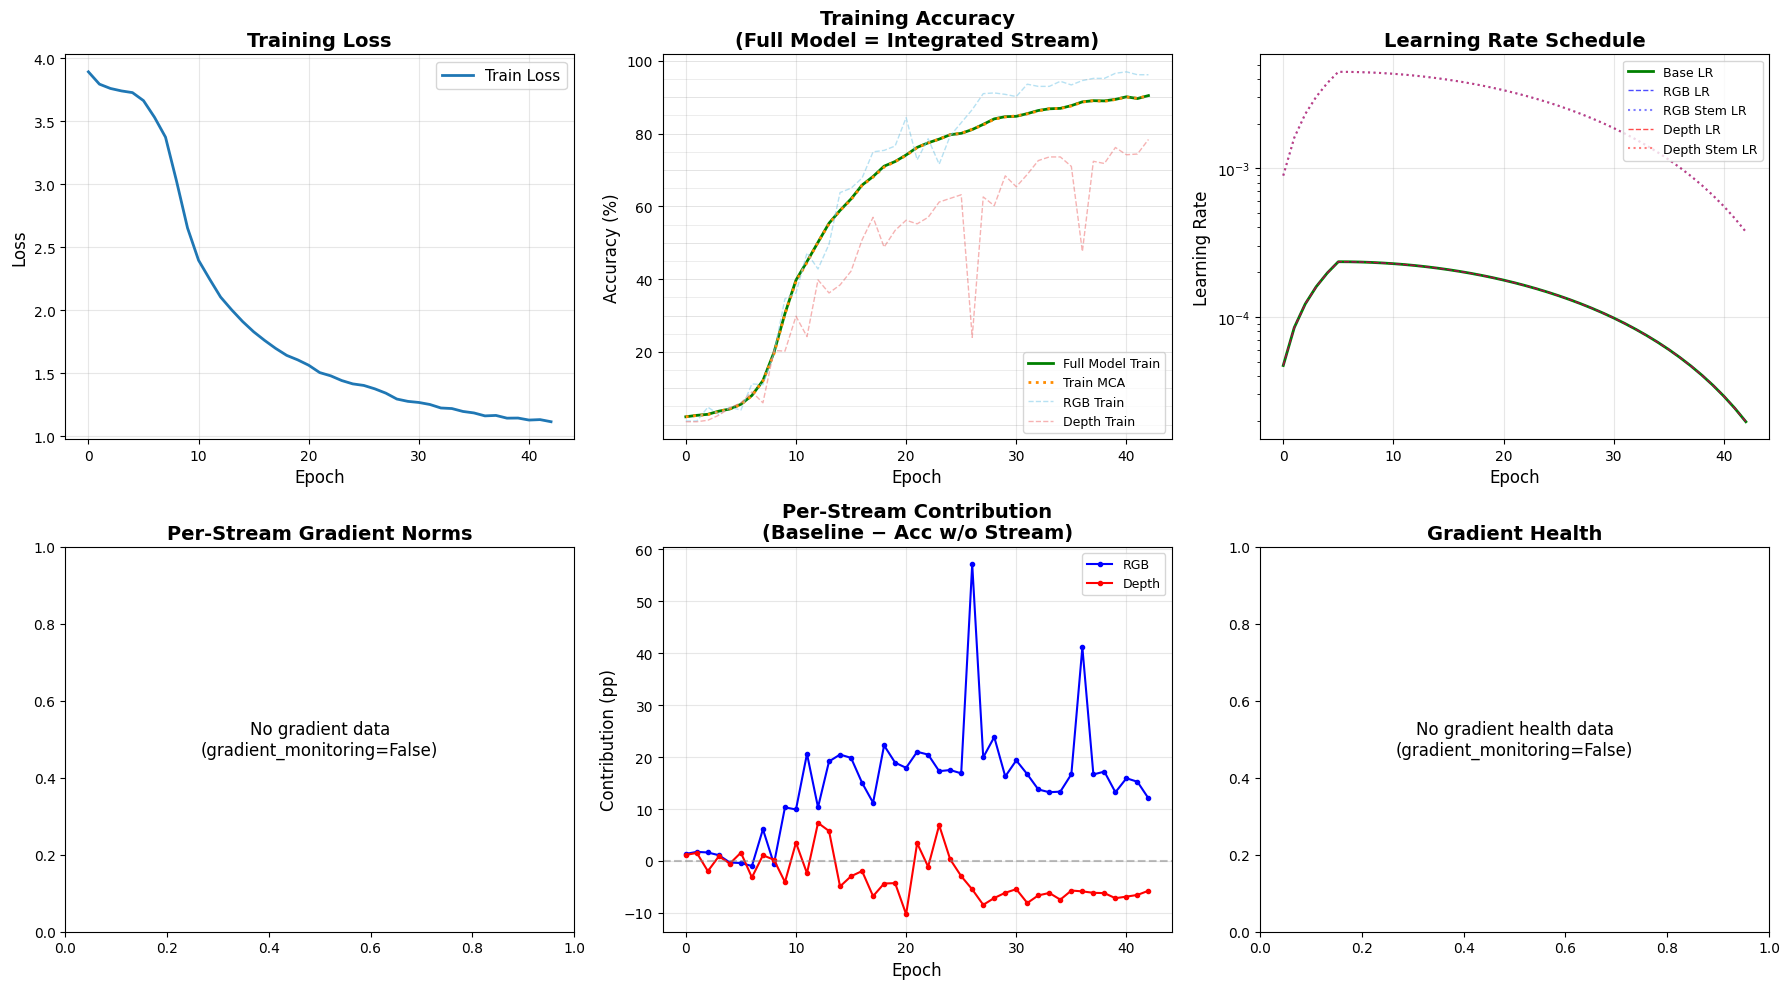

Training diagnostics saved to: /content/drive/MyDrive/msnet_checkpoints/run_20260429_221554/training_diagnostics.pdf


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Standard training curves (restored from original + adapted for no val set) ---

# Loss curve
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curve with per-stream curves
axes[0, 1].plot([acc*100 for acc in history['train_accuracy']], label='Full Model Train', linewidth=2, color='green')
if 'train_mca' in history and history['train_mca']:
    axes[0, 1].plot([m*100 for m in history['train_mca']], label='Train MCA', linewidth=2, color='darkorange', linestyle=':')

# Add per-stream curves (always available with stream_monitoring=True)
stream_train_colors = ['skyblue', 'lightcoral', 'gold', 'lightgreen', 'plum']
stream_val_colors = ['blue', 'red', 'orange', 'green', 'purple']
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    color_idx = i % len(stream_train_colors)
    axes[0, 1].plot([acc*100 for acc in history[f'stream_{i}_train_acc']],
                label=f'{STREAM_LABELS[i]} Train', linewidth=1, alpha=0.6, linestyle='--',
                color=stream_train_colors[color_idx])

axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_yticks([20, 40, 60, 80, 100])
axes[0, 1].set_title('Training Accuracy\n(Full Model = Integrated Stream)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='lower right')
# Draw gridlines manually: alpha=0.3 for multiples of 10, alpha=0.2 for 5, 15, 25...
for y in range(0, 101, 10):
    axes[0, 1].axhline(y=y, color='gray', alpha=0.3, linewidth=0.5)
for y in range(5, 100, 10):
    axes[0, 1].axhline(y=y, color='gray', alpha=0.2, linewidth=0.5)
axes[0, 1].grid(True, axis='x', alpha=0.3)

# Learning rate curve with per-stream LRs
sampled_lrs = history['learning_rates'][::max(1, len(history['learning_rates'])//100)]
axes[0, 2].plot(sampled_lrs, linewidth=2, color='green', label='Base LR')

# Add per-stream LRs (always available with stream_monitoring=True)
lr_colors = ['blue', 'red', 'orange', 'purple', 'brown']
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    color_idx = i % len(lr_colors)
    axes[0, 2].plot(history[f'stream_{i}_lr'], linewidth=1, alpha=0.7, linestyle='--',
                color=lr_colors[color_idx], label=f'{STREAM_LABELS[i]} LR')
    # Plot stem LR if stem_lr_multiplier was active (separate higher LR for conv1)
    if f'stem_{i}_lr' in history:
        axes[0, 2].plot(history[f'stem_{i}_lr'], linewidth=1.5, alpha=0.5, linestyle=':',
                    color=lr_colors[color_idx], label=f'{STREAM_LABELS[i]} Stem LR')

axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Learning Rate', fontsize=12)
axes[0, 2].set_yscale('log')
axes[0, 2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[0, 2].legend(fontsize=9, loc='upper right')
axes[0, 2].grid(True, alpha=0.3)

# --- Row 2: New diagnostics ---

# Gradient norms over epochs (values are dicts with mean/max/min)
if 'gradient_norms' in history and history['gradient_norms']:
    grad_epochs = range(len(history['gradient_norms']))
    for i in range(len(MODEL_CONFIG['stream_input_channels'])):
        key = f'stream_{i}'
        norms = [d.get(key, {}).get('mean', 0) for d in history['gradient_norms']]
        color = stream_val_colors[i % len(stream_val_colors)]
        axes[1, 0].plot(grad_epochs, norms, label=f'{STREAM_LABELS[i]}', color=color, linewidth=1.5)
    shared_norms = [d.get('shared', {}).get('mean', 0) for d in history['gradient_norms']]
    axes[1, 0].plot(grad_epochs, shared_norms, label='Shared', color='gray', linewidth=1.5, linestyle='--')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Gradient Norm (pre-clip, log)', fontsize=12)
    axes[1, 0].set_title('Per-Stream Gradient Norms (mean)', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No gradient data\n(gradient_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 0].transAxes, fontsize=12)
    axes[1, 0].set_title('Per-Stream Gradient Norms', fontsize=14, fontweight='bold')

contrib_keys = [f'stream_{i}_train_acc' for i in range(len(MODEL_CONFIG['stream_input_channels']))]
if contrib_keys[0] in history:
    import math
    n_streams = len(MODEL_CONFIG['stream_input_channels'])
    baseline_vals = history['train_accuracy']
    for i in range(n_streams):
        color = stream_val_colors[i % len(stream_val_colors)]
        other = (i + 1) % n_streams if n_streams == 2 else i
        other_vals = history[f'stream_{other}_train_acc']
        contrib = []
        epochs_eval = []
        for e, (other_acc, base) in enumerate(zip(other_vals, baseline_vals)):
            if not math.isnan(other_acc):
                contrib.append((base - other_acc) * 100)
                epochs_eval.append(e)
        axes[1, 1].plot(epochs_eval, contrib,
                       label=f'{STREAM_LABELS[i]}', color=color, linewidth=1.5, marker='o', markersize=3)
    axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Contribution (pp)', fontsize=12)
    axes[1, 1].set_title('Per-Stream Contribution\n(Baseline − Acc w/o Stream)', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No stream data\n(stream_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Per-Stream Contribution', fontsize=14, fontweight='bold')




# Gradient health status summary
if 'gradient_health' in history and history['gradient_health']:
    axes[1, 2].axis('off')
    health_text = "Gradient Health Summary:\n\n"
    status_counts = {}
    for h in history['gradient_health']:
        status = h.get('status', 'unknown') if isinstance(h, dict) else str(h)
        status_counts[status] = status_counts.get(status, 0) + 1
    for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
        health_text += f"  {status}: {count} epochs\n"
    axes[1, 2].text(0.1, 0.9, health_text, transform=axes[1, 2].transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    axes[1, 2].set_title('Gradient Health', fontsize=14, fontweight='bold')
else:
    axes[1, 2].text(0.5, 0.5, 'No gradient health data\n(gradient_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('Gradient Health', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{checkpoint_dir}/training_diagnostics.pdf", dpi=150, bbox_inches='tight')
plt.show()

print(f"Training diagnostics saved to: {checkpoint_dir}/training_diagnostics.pdf")

## 15. Integration Weight Evolution During Training

How did the learned integration priorities change over training? Did the model start RGB-heavy and shift toward Depth?

In [ ]:
# Stream share of integration weight magnitude over training.
# Aggregates L2 norms across all layers per stream and plots each stream's
# share of the total. Complements the per-layer view in the next cell.
import numpy as np
import matplotlib.pyplot as plt

# Shared visualizer used by this cell and the next two cells.
evo_viz = IntegrationWeightEvolutionVisualizer(stream_labels=STREAM_LABELS)

norms_history = history.get('integration_weight_norms', [])
if not norms_history:
    print("No integration_weight_norms in history -- set TRAIN_CONFIG['track_integration_weights']=True before training.")
else:
    # Each entry is a dict mapping `<layer>.integration_from_streams.<stream_idx>` to L2 norm.
    num_streams = max(int(k.rsplit('.', 1)[1]) for k in norms_history[0].keys()) + 1
    n_epochs = len(norms_history)
    per_stream = np.zeros((num_streams, n_epochs))
    for ei, ep_norms in enumerate(norms_history):
        for k, v in ep_norms.items():
            si = int(k.rsplit('.', 1)[1])
            per_stream[si, ei] += v
    totals = per_stream.sum(axis=0, keepdims=True)
    shares = per_stream / np.where(totals == 0, 1, totals)

    epochs_axis = np.arange(1, n_epochs + 1)
    fig, ax = plt.subplots(figsize=(8, 4))
    for si in range(num_streams):
        ax.plot(epochs_axis, shares[si], marker='.', markersize=4,
                label=STREAM_LABELS.get(si, f'Stream {si}'))
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Fraction of total integration weight L2 norm')
    ax.set_title('Stream share of integration weight magnitude over training')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{checkpoint_dir}/stream_share_evolution.pdf', dpi=150, bbox_inches='tight')
    plt.show()
    print('Stream share evolution saved.')


In [20]:
# Plot norm evolution from training history
if 'integration_weight_norms' in history:
    evo_viz.plot_norm_evolution(history, save_path=f"{checkpoint_dir}/integration_weight_evolution.pdf")
    print(f"Integration weight norm evolution saved.")
else:
    print("No integration weight norm data found in history.")

No integration weight norm data found in history.


In [21]:
# Plot full weight snapshots if saved
snapshot_dir = TRAIN_CONFIG.get('integration_snapshot_path')
if snapshot_dir and os.path.isdir(snapshot_dir) and os.listdir(snapshot_dir):
    # Full grid as PNG (all layers, raster — too heavy for PDF)
    evo_viz.plot_snapshot_heatmaps(snapshot_dir, save_path=f"{checkpoint_dir}/integration_weight_snapshots.png")
    print(f"Integration weight snapshot heatmaps saved (full, PNG).")

    # Early layers only as PDF (vector, paper-ready)
    for layer_name in ['conv1', 'layer1']:
        evo_viz.plot_snapshot_heatmaps(
            snapshot_dir,
            layer_filter=layer_name,
            save_path=f"{checkpoint_dir}/integration_weight_snapshots_{layer_name}.pdf"
        )
    print(f"Integration weight snapshot heatmaps saved (conv1 + layer1, PDF).")
else:
    print("No integration weight snapshots found.")

No integration weight snapshots found.


In [ ]:
# Visualize learned first-layer conv filters (7x7 kernels) per stream
iw_viz = IntegrationWeightVisualizer(model, stream_labels=STREAM_LABELS)
iw_viz.visualize_conv1_filters(save_path=f'{checkpoint_dir}/conv1_filters.pdf')
print('Conv1 filter visualization saved.')


## 16. Save Results & Model

In [ ]:
import json
import torch

print("=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Save training history as JSON
history_path = f"{checkpoint_dir}/training_history.json"
with open(history_path, 'w') as f:
    # Build pathway analysis dict with all returned data
    pa_json = {
        'accuracy': {k: float(v) for k, v in pathway_analysis['accuracy'].items()},
        'loss': {k: float(v) for k, v in pathway_analysis['loss'].items()},
        'feature_norms': {k: float(v) for k, v in pathway_analysis['feature_norms'].items()},
        'samples_analyzed': pathway_analysis['samples_analyzed'],
    }

    json_history = {
        'train_loss': [float(x) for x in history['train_loss']],
        'train_accuracy': [float(x) for x in history['train_accuracy']],
        'learning_rates': [float(x) for x in history['learning_rates']],
        # Per-stream and stem LR curves (when stream_monitoring=True)
        **{f'stream_{i}_lr': [float(x) for x in history.get(f'stream_{i}_lr', [])]
           for i in range(2)},
        **{f'stem_{i}_lr': [float(x) for x in history.get(f'stem_{i}_lr', [])]
           for i in range(2) if f'stem_{i}_lr' in history},
        'model_config': MODEL_CONFIG,
        'dataset_config': DATASET_CONFIG,
        'augmentation_config': AUGMENTATION_CONFIG.to_dict(),
        'stream_specific_config': STREAM_SPECIFIC_CONFIG,
        'scheduler_config': SCHEDULER_CONFIG,
        'training_config': {k: str(v) if not isinstance(v, (int, float, bool, type(None))) else v for k, v in TRAIN_CONFIG.items()},
        'train_mca': [float(x) for x in history.get('train_mca', [])],
        'test_results': {
            'loss': float(results['loss']),
            'accuracy': float(results['accuracy']),
            'mean_class_accuracy': float(results.get('mean_class_accuracy', 0)),
        },
        'pathway_analysis': pa_json,
    }

    json.dump(json_history, f, indent=2)

print(f"Training history saved: {history_path}")

# Save final model
final_model_path = f"{checkpoint_dir}/final_model.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.optimizer.state_dict(),
    'scheduler_state_dict': model.scheduler.state_dict() if model.scheduler else None,
    'config': MODEL_CONFIG,
    'history': history,
    'test_accuracy': results['accuracy']
}, final_model_path)

print(f"Final model saved: {final_model_path}")

# List saved files
print(f"\nAll results saved to: {checkpoint_dir}")
!ls -lh {checkpoint_dir}

print("\n" + "=" * 60)

## 17. Internal CNN Visualization Suite

Everything below runs on the **trained model** with the **test set**. Each cell is independent — run whichever analyses interest you.

In [ ]:
# --- 17a. Feature Map Visualization ---
# "What does the CNN see at each layer?"
# Three modes: full model, single-stream isolated, ablation
# Compare layer1 (early/texture) vs layer4 (late/semantic)

fm_viz = FeatureMapVisualizer(model, stream_labels=STREAM_LABELS)

# Get a single test sample
test_iter = iter(test_loader)
sample_batch = next(test_iter)
*stream_batches, labels = sample_batch
# Take first sample
stream_inputs = [s[0:1].to(model.device) for s in stream_batches]

print(f"Sample label: {labels[0].item()} ({class_names[labels[0].item()] if 'class_names' in dir() else '?'})")

for layer in ['layer1', 'layer4']:
    print(f"\n{'='*60}")
    print(f"  {layer.upper()} FEATURE MAPS")
    print(f"{'='*60}")

    # Mode 1: Full model view (all streams + integrated)
    print(f"\n--- Full Model View ({layer}) ---")
    fm_viz.visualize(stream_inputs, layer=layer, top_k=8,
                     save_path=f"{checkpoint_dir}/featuremaps_full_{layer}.png")

    # Mode 2: Per-stream isolated views
    for i, label in STREAM_LABELS.items():
        print(f"\n--- {label} Stream Isolated View ({layer}) ---")
        fm_viz.visualize(stream_inputs, layer=layer, mode='stream', stream_idx=i, top_k=8,
                         save_path=f"{checkpoint_dir}/featuremaps_{label.lower()}_{layer}.png")

    # Mode 3: Ablation (what happens when we remove a stream?)
    for i, label in STREAM_LABELS.items():
        print(f"\n--- Ablation: {label} Blanked ({layer}) ---")
        fm_viz.visualize(stream_inputs, layer=layer, mode='ablation', stream_idx=i, top_k=8,
                         save_path=f"{checkpoint_dir}/featuremaps_ablation_{label.lower()}_{layer}.png")

# Batch-averaged feature maps at both layers
for layer in ['layer1', 'layer4']:
    print(f"\n--- Batch-Averaged Feature Maps ({layer}, 32 samples) ---")
    fm_viz.visualize_batch(test_loader, layer=layer, n=32, top_k=8,
                           save_path=f"{checkpoint_dir}/featuremaps_batch_avg_{layer}.png")

print("\nFeature map visualizations complete!")

In [ ]:
# --- 17b. Stream Contribution Decomposition ---
# THE unique MSNet visualization: how much does each stream contribute
# to each neuron's activation in the integrated pathway?

contrib_viz = StreamContributionVisualizer(model, stream_labels=STREAM_LABELS)

# Single image contribution at layer4
print("--- Stream Contributions (layer4, single sample) ---")
contrib_viz.visualize(stream_inputs, layer='layer4',
                      save_path=f"{checkpoint_dir}/contributions_layer4.pdf")

# Batch-averaged contributions (more representative)
print("\n--- Batch-Averaged Contributions (layer4, 32 samples) ---")
contrib_viz.visualize_batch(test_loader, layer='layer4', n=32,
                            save_path=f"{checkpoint_dir}/contributions_batch_layer4.pdf")

# Multi-layer comparison
for layer in ['layer1', 'layer2', 'layer3', 'layer4']:
    print(f"\n--- Contributions at {layer} ---")
    contrib_viz.visualize(stream_inputs, layer=layer,
                          save_path=f"{checkpoint_dir}/contributions_{layer}.pdf")

print("\nStream contribution decomposition complete!")

In [ ]:
# --- 17c. Stream-Decomposed Grad-CAM ---
# Where does each stream focus its attention?

gradcam = StreamGradCAM(model, stream_labels=STREAM_LABELS)

# Integrated Grad-CAM (standard: where does the full model look?)
print("--- Integrated Grad-CAM (layer4) ---")
gradcam.visualize(stream_inputs, layer='layer4', mode='integrated',
                  save_path=f"{checkpoint_dir}/gradcam_integrated_layer4.png")

# Per-stream isolated Grad-CAM (where does each stream look independently?)
for i, label in STREAM_LABELS.items():
    print(f"\n--- {label} Stream Grad-CAM (layer4) ---")
    gradcam.visualize(stream_inputs, layer='layer4', mode='stream', stream_idx=i,
                      save_path=f"{checkpoint_dir}/gradcam_{label.lower()}_layer4.png")

# Decomposed mode: contribution maps weighted by Grad-CAM importance
print("\n--- Decomposed Grad-CAM (layer4) ---")
gradcam.visualize(stream_inputs, layer='layer4', mode='decomposed',
                  save_path=f"{checkpoint_dir}/gradcam_decomposed_layer4.png")

# Multi-layer Grad-CAM (early=texture, late=semantics)
for layer in ['layer2', 'layer3', 'layer4']:
    print(f"\n--- Integrated Grad-CAM at {layer} ---")
    gradcam.visualize(stream_inputs, layer=layer, mode='integrated',
                      save_path=f"{checkpoint_dir}/gradcam_integrated_{layer}.png")

print("\nGrad-CAM visualizations complete!")

In [ ]:
# --- 17d. Integration Weight Visualization ---
# Visualize the learned integration_from_streams weights per layer

iw_viz = IntegrationWeightVisualizer(model, stream_labels=STREAM_LABELS)

# Weight heatmaps per layer and stream
print('--- Integration Weights (Heatmaps) ---')
iw_viz.visualize_weights(save_path=f'{checkpoint_dir}/integration_weights.png')

# Cross-stream comparison (relative weight magnitudes per layer)
print('\n--- Cross-Stream Weight Comparison ---')
iw_viz.visualize_cross_stream(save_path=f'{checkpoint_dir}/integration_cross_stream.pdf')

# Effective rank via SVD (how low-dimensional is the integration?)
print('\n--- Effective Rank (SVD) ---')
ranks = iw_viz.compute_effective_rank()
for layer, r in ranks.items():
    print(f'  {layer}: {[f"{x:.1f}" for x in r]}')

print('\nIntegration weight visualization complete!')

In [ ]:
# --- 17e. Stream Redundancy Analysis ---
# Are RGB and Depth learning the same features? Or complementary ones?
# Uses centered cosine similarity between stream feature maps at each layer.

redundancy = StreamRedundancyAnalyzer(model, stream_labels=STREAM_LABELS)

print('--- Stream Redundancy (Centered Cosine Similarity) ---')
sim_results = redundancy.analyze(
    test_loader,
    n=128,  # Average over 128 samples
    save_path=f'{checkpoint_dir}/stream_redundancy.pdf'
)

# Print similarity matrices
for layer_name, sim_matrix in sim_results.items():
    print(f'\n{layer_name}:')
    for i in range(sim_matrix.shape[0]):
        row = '  '.join(f'{sim_matrix[i,j]:.3f}' for j in range(sim_matrix.shape[1]))
        print(f'  {STREAM_LABELS.get(i, f"S{i}")}: {row}')

print('\nStream redundancy analysis complete!')

In [ ]:
# --- 17f. Per-Class Stream Dominance ---
# Which scenes rely on RGB vs Depth?
# "Depth matters more for bathrooms, RGB dominates corridors"

# Build class name mapping
class_name_map = {i: name for i, name in enumerate(class_names)} if 'class_names' in dir() else None

dominance = PerClassDominanceAnalyzer(model, stream_labels=STREAM_LABELS)

print('--- Per-Class Stream Dominance (layer4) ---')
class_dominance = dominance.analyze(
    test_loader,
    layer='layer4',
    class_names=class_name_map,
    save_path=f'{checkpoint_dir}/per_class_dominance.pdf'
)

# Print per-class ratios
print('\nPer-class stream contribution ratios:')
for cls_idx, ratios in sorted(class_dominance.items()):
    name = class_name_map[cls_idx] if class_name_map else f'Class {cls_idx}'
    ratio_str = ', '.join(f'{STREAM_LABELS.get(i, f"S{i}")}: {r:.2%}' for i, r in enumerate(ratios))
    print(f'  {name}: {ratio_str}')

print('\nPer-class dominance analysis complete!')

In [ ]:
# --- 17g. Misclassification Analysis + Sample Comparison ---
# Find misclassified samples and compare with correctly classified ones

print('--- Finding Misclassified Samples ---')
misclassified = find_misclassified(model, test_loader, n=10)

print(f'Found {len(misclassified)} misclassified samples:')
for i, mc in enumerate(misclassified[:5]):
    true_name = class_names[mc['true_label']] if 'class_names' in dir() else str(mc['true_label'])
    pred_name = class_names[mc['predicted_label']] if 'class_names' in dir() else str(mc['predicted_label'])
    print(f'  [{i}] True: {true_name}, Predicted: {pred_name}, Confidence: {mc["confidence"]:.2%}')

# Grad-CAM on first misclassified sample
if misclassified:
    mc_sample = misclassified[0]
    mc_inputs = [s.to(model.device) for s in mc_sample['stream_inputs']]
    true_name = class_names[mc_sample['true_label']] if 'class_names' in dir() else str(mc_sample['true_label'])
    pred_name = class_names[mc_sample['predicted_label']] if 'class_names' in dir() else str(mc_sample['predicted_label'])
    print(f'\n--- Grad-CAM on Misclassified: True={true_name}, Pred={pred_name} ---')
    gradcam.visualize(mc_inputs, layer='layer4', mode='decomposed',
                      save_path=f'{checkpoint_dir}/gradcam_misclassified_0.png')

# Compare correct vs misclassified from same class
if misclassified:
    target_class = misclassified[0]['true_label']
    print(f'\n--- Finding correctly classified sample from class {class_names[target_class] if "class_names" in dir() else target_class} ---')

    # Find a correctly classified sample from the same class
    correct_sample = None
    model.eval()
    with torch.no_grad():
        for batch_data in test_loader:
            *stream_batches, targets = batch_data
            stream_batches_dev = [s.to(model.device) for s in stream_batches]
            targets_dev = targets.to(model.device)
            logits = model(stream_batches_dev)
            preds = logits.argmax(dim=1)
            # Find correctly classified samples of the target class
            mask = (targets_dev == target_class) & (preds == target_class)
            if mask.any():
                idx = mask.nonzero(as_tuple=True)[0][0].item()
                correct_sample = {
                    'stream_inputs': [s[idx:idx+1].cpu() for s in stream_batches],
                    'true_label': target_class,
                    'predicted_label': target_class,
                    'confidence': torch.softmax(logits[idx], dim=0)[target_class].item(),
                }
                break

    if correct_sample is not None:
        print(f'  Found correct sample (confidence: {correct_sample["confidence"]:.2%})')
        print('\n--- Correct vs Misclassified Comparison ---')
        compare_samples(
            model,
            correct_sample=correct_sample,
            misclassified_sample=misclassified[0],
            layer='layer4',
            stream_labels=STREAM_LABELS,
            save_path=f'{checkpoint_dir}/compare_samples.png'
        )
    else:
        print('  No correctly classified sample found for this class.')

print('\nMisclassification analysis complete!')

In [ ]:
# --- 17h. Train vs Test Activation Divergence ---
# Does the model see different activation distributions on train vs test?
# Uses MMD (Maximum Mean Discrepancy) per layer.

div_analyzer = ActivationDivergenceAnalyzer(model)

print('--- Train vs Test Activation Divergence ---')
divergence = div_analyzer.analyze(
    train_loader,
    test_loader,
    n=128,
    save_path=f'{checkpoint_dir}/activation_divergence.pdf'
)

for layer_name, metrics in divergence.items():
    print(f'  {layer_name}: MMD={metrics["mmd"]:.4f}')

print('\nActivation divergence analysis complete!')

In [ ]:
# --- 17i. BN Stats Reset Experiment (Oracle Diagnostic) ---
# WARNING: This is a DIAGNOSTIC tool, not a deployable fix.
# It recomputes BN running stats on test data (oracle) to check if
# BN statistics drift causes the generalization gap.

import copy

# Save original accuracy
original_test_results = model.evaluate(test_loader)
original_acc = original_test_results['accuracy']
print(f'Original test accuracy: {original_acc*100:.2f}%')

# Control: recompute BN stats on TRAIN set (should be ~same)
print('\n--- Control: Recompute BN stats on TRAIN set ---')
model_control = copy.deepcopy(model)
reset_bn_stats(model_control, train_loader)
control_results = model_control.evaluate(test_loader)
control_acc = control_results['accuracy']
print(f'After train BN reset: {control_acc*100:.2f}% (delta: {(control_acc-original_acc)*100:+.2f}%)')

# Oracle: recompute BN stats on TEST set
print('\n--- Oracle: Recompute BN stats on TEST set ---')
model_oracle = copy.deepcopy(model)
reset_bn_stats(model_oracle, test_loader)
oracle_results = model_oracle.evaluate(test_loader)
oracle_acc = oracle_results['accuracy']
print(f'After test BN reset (oracle): {oracle_acc*100:.2f}% (delta: {(oracle_acc-original_acc)*100:+.2f}%)')

# Interpretation
print('\n--- Interpretation ---')
oracle_delta = (oracle_acc - original_acc) * 100
if abs(oracle_delta) > 2:
    print(f'BN stats drift accounts for ~{oracle_delta:+.1f}% of the gap.')
    print('Consider: test-time BN adaptation, larger batch size, or more training data.')
else:
    print(f'BN stats drift is minimal ({oracle_delta:+.1f}%). Gap is likely from other sources.')

del model_control, model_oracle  # Free memory
print('\nBN reset experiment complete!')

## 18. Summary

All training diagnostics and visualization analyses are saved to the checkpoint directory on Google Drive.

**Saved models:**
- `best_model.pt` - Best model checkpoint (by val_mca; restored before test eval via restore_best_weights=True)
- `final_model.pt` - Final model with full state dict, optimizer, scheduler, history

**Saved data:**
- `training_history.json` - Full training history, configs, test results, pathway analysis
- `integration_snapshots/` - Periodic full integration weight snapshots (every N epochs)

**Saved visualizations:**
- `training_diagnostics.pdf` - 2x3 grid: loss, accuracy, LR, gradient norms, stream losses, gradient health
- `integration_weight_evolution.pdf` - Per-stream integration weight norms over training epochs
- `integration_weight_snapshots.png` - Detailed weight heatmaps at snapshot epochs
- `featuremaps_*.png` - What the CNN sees (full model, per-stream isolated, ablation, batch-averaged)
- `contributions_*.pdf` - Per-stream contribution magnitudes at each layer
- `gradcam_*.png` - Spatial attention maps (integrated, per-stream, decomposed, multi-layer)
- `gradcam_misclassified_0.png` - Decomposed Grad-CAM on a misclassified sample
- `integration_weights.png` - Learned fusion weight heatmaps per layer
- `integration_cross_stream.pdf` - Cross-stream weight magnitude comparison
- `stream_redundancy.pdf` - Centered cosine similarity between stream features per layer
- `per_class_dominance.pdf` - Which classes rely on RGB vs Depth
- `activation_divergence.pdf` - Train vs test activation distribution shift (MMD) per layer
- `compare_samples.png` - Correct vs misclassified side-by-side (Grad-CAM + contributions)
